# Predicting drug clearance under latent genetic heterogeneity


### 1. An Overview of Kernel Gradient Discrepancy (KGD)

Kernel Gradient Discrepancy provides a scalar diagnostic of how close an empirical particle swarm, $Q_n$, is to a target distribution. The squared KGD can be fundamentally expressed as a double expectation over the distribution $Q$:$$\mathrm{KGD}^2(Q) = \iint v_Q(\vartheta)^T K(\vartheta, \vartheta') v_Q(\vartheta') \, dQ(\vartheta) \, dQ(\vartheta')$$Here, $K(\vartheta, \vartheta')$ is a positive-definite kernel that evaluates the similarity between particles in the parameter space. In this implementation, you can utilize two primary radial kernels:
- Inverse Multi-Quadric (IMQ): $K(\vartheta, \vartheta') = (c^2 + \Vert{}\vartheta - \vartheta'\Vert{}^2)^\beta$
- Radial Basis Function (RBF): $K(\vartheta, \vartheta') = \exp\left(-\frac{\Vert{}\vartheta - \vartheta'\Vert{}^2}{h}\right)$.

For both kernels, the bandwidth scale (such as $h$) is dynamically computed at runtime using the median heuristic based on the pairwise distances across the particle swarm. 
To compute this diagnostic in practice for an empirical particle swarm $Q_n$ consisting of $N_p$ discrete particles, the continuous double integral reduces to a computable sample version:$$\mathrm{KGD}^2(Q_n) = \frac{1}{N_p^2} \sum_{j=1}^{N_p} \sum_{l=1}^{N_p} h_{Q_n}(\vartheta^{(j)}, \vartheta^{(l)})$$

Where $h_Q(\vartheta, \vartheta') = b_Q(\vartheta)^T K(\vartheta, \vartheta') b_Q(\vartheta') - b_Q(\vartheta)^T \nabla_{\vartheta'} K(\vartheta, \vartheta') - \nabla_\vartheta K(\vartheta, \vartheta')^T b_Q(\vartheta') + \mathrm{Tr}\big( \nabla_\vartheta \nabla_{\vartheta'} K(\vartheta, \vartheta') \big)$

and $b(\vartheta, Q) = \frac{\lambda_n}{n} \sum_{i=1}^{n} \nabla_\vartheta \left( \frac{\delta S(P_Q, x_i)}{\delta q(\vartheta)} \right) - \nabla_\vartheta\log\pi(\vartheta)$, our known drift.

In this sample estimator, $h_{Q_n}(\vartheta^{(j)}, \vartheta^{(l)})$ evaluates the pairwise interaction between particles $j$ and $l$ using the known deterministic drift forces and the spatial derivatives of the chosen kernel $K$.


## Setup & Cohort Simulation

In clinical pharmacology, a central problem is predicting how quickly a patient eliminates a drug from their body (their clearance, $\text{CL}$). Clearance is typically modeled on the log scale, $y = \log(\text{CL})$, where physiological covariates like body weight and age act multiplicatively.

For this study, we simulate a cohort of $n = 500$ patients based on a literature-calibrated mixture model (Verma et al. 2021, Soedarsono et al. 2022, Anderson & Holford 2008) for a drug metabolized by the NAT2 enzyme. Genetic variation in human populations creates discrete metabolic sub-populations with distinct baseline clearance rates. We parameterize the population frequencies and baseline clearances ($\text{CL}$) as follows:

*   Slow metabolizers: 56% of patients ($p = 0.56$) with a baseline clearance of $17.7$ L/h.
*   Intermediate metabolizers: 33% of patients ($p = 0.33$) with a baseline clearance of $37.8$.
*   Rapid metabolizers: 11% of patients ($p = 0.11$) with a baseline clearance of $55.9$.

Individual clearance also scales with body weight via standard allometric scaling (exponent $\eta = 0.75$) and declines modestly with age (slope $\alpha = -0.10$). Because patient genotypes are unobserved in many clinical studies, we rely solely on measured weight, age, and drug clearance. The true distribution of $y$ given weight and age is therefore a three-component Gaussian location mixture:

$$y_i \mid \ell_i, c_i \sim \sum_{g=0}^2 p_g \mathcal{N}(\log \text{CL}_g + \eta \ell_i + \alpha c_i, \sigma^2)$$

To generate the synthetic cohort data, the patient covariates and within-group noise are simulated using the following distributions and standardizations:

*   Body Weight: Sampled as $W_i \sim \mathcal{N}_{[32,95]}(55, 10^2)$ kg, and standardized as $\ell_i = \log(W_i/55)$.
*   Age: Sampled as $A_i \sim \mathcal{U}(18, 65)$ years, and centered as $c_i = (A_i - 40)/10$.
*   Residual Noise: The within-group standard deviation is set to $\sigma = 0.30$.

In [5]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
from scipy.stats import truncnorm

import pymc_prop as pro

az.style.use("arviz-variat")


In [6]:
N = 500
SEED = 2026
sigma = 0.30
eta = 0.75
alpha = -0.10
freq = np.array([0.56, 0.33, 0.11])
clearances = np.array([17.7, 37.8, 55.9])
log_clearances = np.log(clearances)


def simulate_nat2(
    n=N,
    seed=SEED,
    freq=freq,
    clearance=clearances,
    eta=eta,
    alpha=alpha,
    sigma=sigma,
):
    """Draw n patients. Returns observable outcome y and covariates; phenotype is latent."""
    rng = np.random.default_rng(seed)
    p = np.asarray(freq) / np.sum(freq)

    genotype = rng.choice(len(p), size=n, p=p)
    weight = truncnorm(-2.3, 4.0, loc=55.0, scale=10.0).rvs(n, random_state=rng)
    age = rng.uniform(18.0, 65.0, n)

    log_weight = np.log(weight / 55.0)  # ell_i = log(W_i / 55)
    centred_age = (age - 40.0) / 10.0   # c_i = (A_i - 40) / 10
    log_cl = np.log(np.asarray(clearance))
    y = (
        log_cl[genotype]
        + eta * log_weight
        + alpha * centred_age
        + sigma * rng.normal(size=n)
    )
    return y, log_weight, centred_age, genotype, weight, age


y, log_weight, centred_age, genotype, weight, age = simulate_nat2()

# plotting limits around component means
xlim = (log_clearances.min() - 3 * sigma, log_clearances.max() + 3 * sigma)


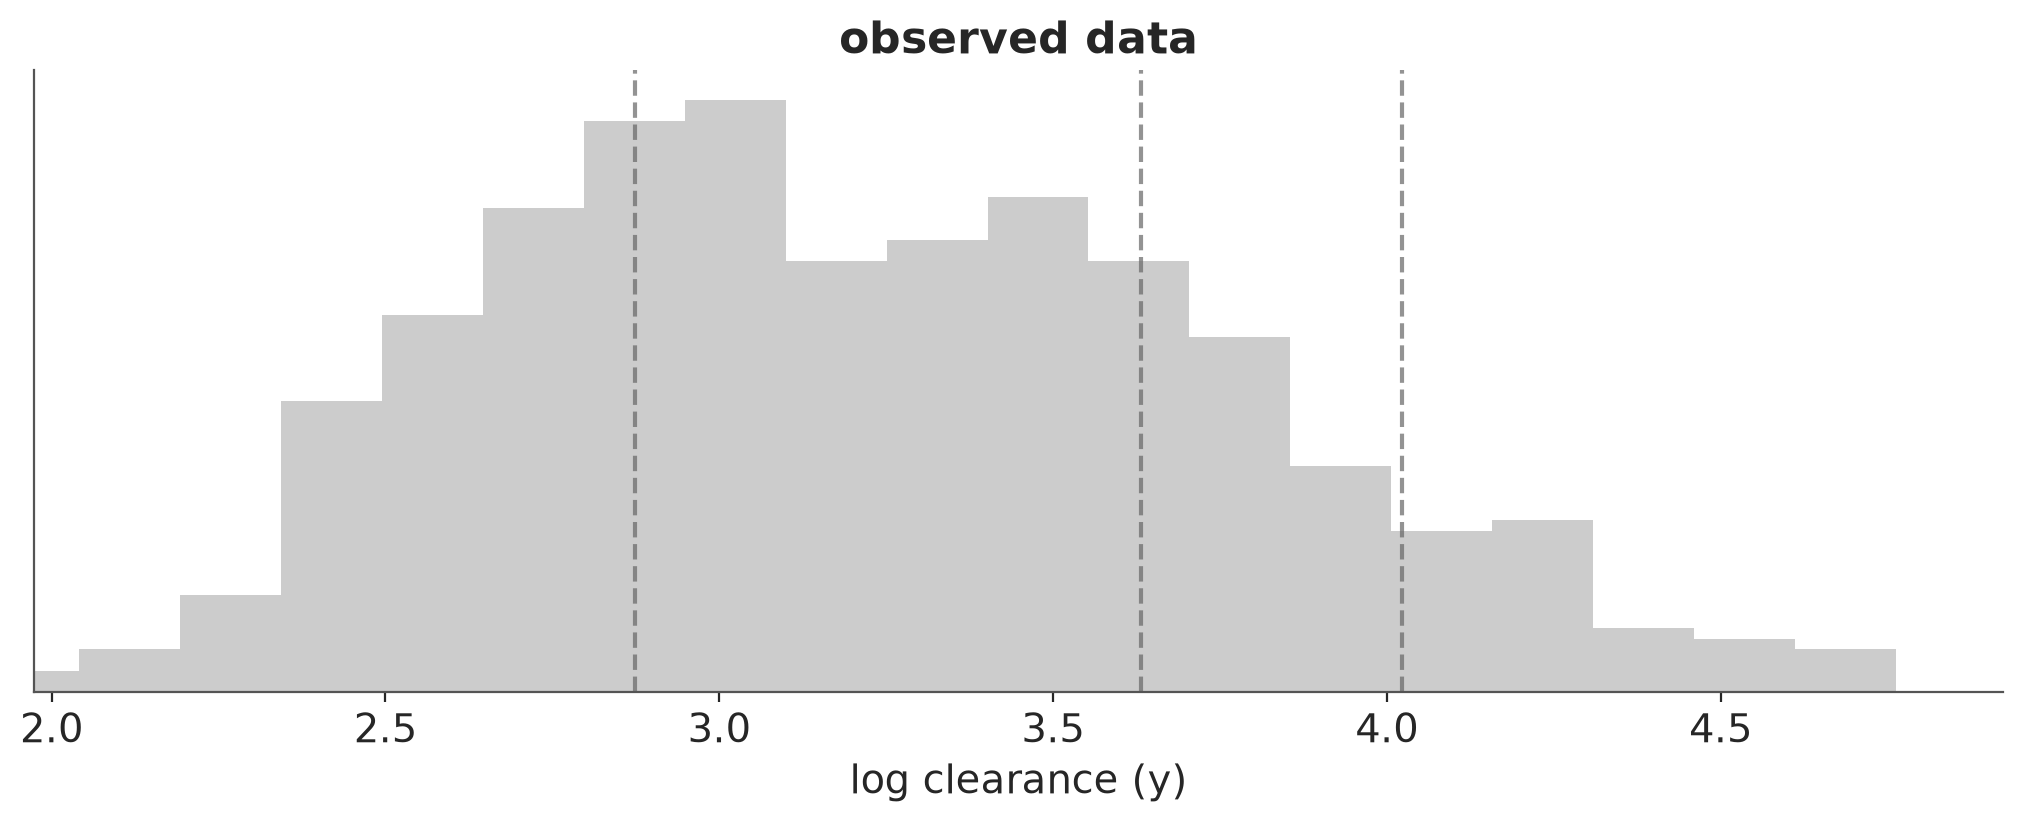

In [7]:
# histogram of the simulated data (verify multimodality)
_, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    y,
    bins=20,
    color="0.8",
    edgecolor=None,
)
for cl in log_clearances:
    ax.axvline(cl, color="0.4", linestyle="--", alpha=0.7)
ax.set(title="observed data", xlabel="log clearance (y)", xlim=xlim, yticks=[]);


## PyMC model (misspecified unimodal likelihood)

We place standard normal priors on the regression coefficients $\beta_0, \beta_1, \beta_2$ and define
$y_i \mid \beta \sim \mathcal{N}(\beta_0 + \beta_1\,\ell_i + \beta_2\,c_i,\ \sigma^2)$ with known within-group noise $\sigma = 0.30$.

In [8]:
with pm.Model() as model:
    # Intentionally bad prior to demonstrate gradient flow and particle splitting
    beta0 = pm.Normal("beta0", mu=2, sigma=1) 
    beta1 = pm.Normal("beta1", mu=0.75, sigma=1)
    beta2 = pm.Normal("beta2", mu=0.5, sigma=1)

    mu = beta0 + beta1 * log_weight + beta2 * centred_age
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)


In [9]:
# Run standard Bayesian MCMC baseline for comparison
with model:
    idata_bayes = pm.sample(
        draws=1000,
        tune=1000,
        random_seed=SEED,
        progressbar=True,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, beta2]


/home/patrideo/micromamba/envs/pymc-dev-prop/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


### Run the sampler

Sampling uses a particle-discretized Wasserstein gradient flow on $N = 500$ observations. We set `tune=0` so every simulation step is retained for the trajectory plot (`n_steps` maps to the `draw` coordinate).

We use 60 particles, 800 steps, `step_size=None` (FUSE adaptive schedule; floor `r_eps=1e-5`), `kgd_interval=10`, and learning rate $\lambda_n = 1$ (default). Below we inspect the DataTree output, plot KGD and FUSE diagnostics, particle trajectories, and a posterior predictive check in $y$-space.

In [10]:
dt = pro.sample_pro(
    model=model,
    n_particles=64,
    n_steps=4000,
    step_size=None,
    r_eps=1e-5,
    tune=0,
    kgd_interval=5,
    random_seed=SEED,
)


## ArviZ DataTree output

`sample_pro` returns an ArviZ [DataTree](https://python.arviz.org/projects/base/en/latest/tutorial/WorkingWithDataTree.html). Coordinates: `draw` is the retained index, `step` is the simulation step number, and `chain` is the particle index. Particles are ensemble trajectories, not independent MCMC chains, so diagnostics such as `az.rhat` and `az.ess` are not meaningful here.

Groups:
- `posterior`: particle clouds over retained steps (`sample_dims=["draw", "chain"]`).
- `mixture_log_predictive`: analytic log marginal $\log p_{\hat Q}(y_i)$ at observed data (dims `draw`, obs — no `chain`).
- `sample_stats`: flow diagnostics. `mixture_log_predictive_total` sums mixture log predictive over observations (broadcast to `chain` for ArviZ layout). `mean_log_score` averages per-particle log-score sums, which is a different quantity. With FUSE (`step_size=None`), it stores `fuse_step_size`, `fuse_gradient_energy`, and `fuse_half_step_distance_sq`. With `kgd_interval`, it also records `kgd`.
- `posterior_predictive`: mixture PPC draws from `sample_posterior_predictive_pro` (added in a later cell). Shape `(draw, …)` with `sample_dims=["draw"]` — one row per retained step, aligned with `posterior.draw` / `step`, no `chain` dim.

In [11]:
dt


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (draw: 4000, chain: 64)
│       Coordinates:
│         * draw     (draw) int64 32kB 0 1 2 3 4 5 6 ... 3994 3995 3996 3997 3998 3999
│           step     (draw) int64 32kB 0 1 2 3 4 5 6 ... 3994 3995 3996 3997 3998 3999
│         * chain    (chain) int64 512B 0 1 2 3 4 5 6 7 8 ... 55 56 57 58 59 60 61 62 63
│       Data variables:
│           beta0    (draw, chain) float64 2MB 2.262 2.038 1.415 ... 3.547 2.813 3.078
│           beta1    (draw, chain) float64 2MB 1.873 2.136 1.792 ... 0.7494 0.5863
│           beta2    (draw, chain) float64 2MB 0.5429 1.147 -1.322 ... -0.06861 -0.3001
│       Attributes:
│           created_at:                 2026-10-05T16:04:19.911198+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['draw', 'chain']
│           inference_library:          pymc
│           inference_library_version:  6.0.0
├── Group: /observed_data
│       Dimensions:  (y_dim_0: 500)
│       Coordinates:
│         * y_dim_0  (y_dim_0) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
│       Data variables:
│           y        (y_dim_0) float64 4kB 2.389 3.486 3.427 3.028 ... 3.018 2.548 2.442
│       Attributes:
│           created_at:                 2026-10-05T16:04:20.227043+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /log_likelihood
│       Dimensions:  (draw: 4000, chain: 64, y_dim_0: 500)
│       Coordinates:
│         * draw     (draw) int64 32kB 0 1 2 3 4 5 6 ... 3994 3995 3996 3997 3998 3999
│           step     (draw) int64 32kB 0 1 2 3 4 5 6 ... 3994 3995 3996 3997 3998 3999
│         * chain    (chain) int64 512B 0 1 2 3 4 5 6 7 8 ... 55 56 57 58 59 60 61 62 63
│         * y_dim_0  (y_dim_0) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
│       Data variables:
│           y        (draw, chain, y_dim_0) float64 1GB -6.213 -31.4 ... -1.699 0.1496
│       Attributes:
│           created_at:                 2026-10-05T16:04:19.911198+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['draw', 'chain']
│           inference_library:          pymc
│           inference_library_version:  6.0.0
├── Group: /sample_stats
│       Dimensions:                       (draw: 4000, chain: 64)
│       Coordinates:
│         * draw                          (draw) int64 32kB 0 1 2 3 ... 3997 3998 3999
│           step                          (draw) int64 32kB 0 1 2 3 ... 3997 3998 3999
│         * chain                         (chain) int64 512B 0 1 2 3 4 ... 60 61 62 63
│       Data variables:
│           particle_spread               (draw, chain) float64 2MB 1.07 1.07 ... 0.4319
│           learning_rate                 (draw, chain) float64 2MB 1.0 1.0 ... 1.0 1.0
│           beta0_spread                  (draw, chain) float64 2MB 1.005 ... 0.426
│           beta1_spread                  (draw, chain) float64 2MB 1.098 ... 0.7358
│           beta2_spread                  (draw, chain) float64 2MB 1.106 ... 0.1338
│           mean_log_score                (draw, chain) float64 2MB -1.472e+04 ... -1...
│           se_log_score                  (draw, chain) float64 2MB 1.49e+03 ... 146.2
│           fuse_gradient_energy          (draw, chain) float64 2MB 7.398e+05 ... 4.8...
│           fuse_half_step_distance_sq    (draw, chain) float64 2MB 0.0 0.0 ... 4.971
│           fuse_step_size                (draw, chain) float64 2MB 1e-05 ... 0.0002845
│           kgd                           (draw, chain) float64 2MB 227.6 227.6 ... nan
│           mixture_log_predictive_total  (draw, chain) float64 2MB -914.2 ... -365.4
│      

## Kernel Gradient Discrepancy (KGD) diagnostic

When `kgd_interval` is specified, `sample_pro` records the V-statistic in `sample_stats["kgd"]`. We plot the raw metric to check convergence.

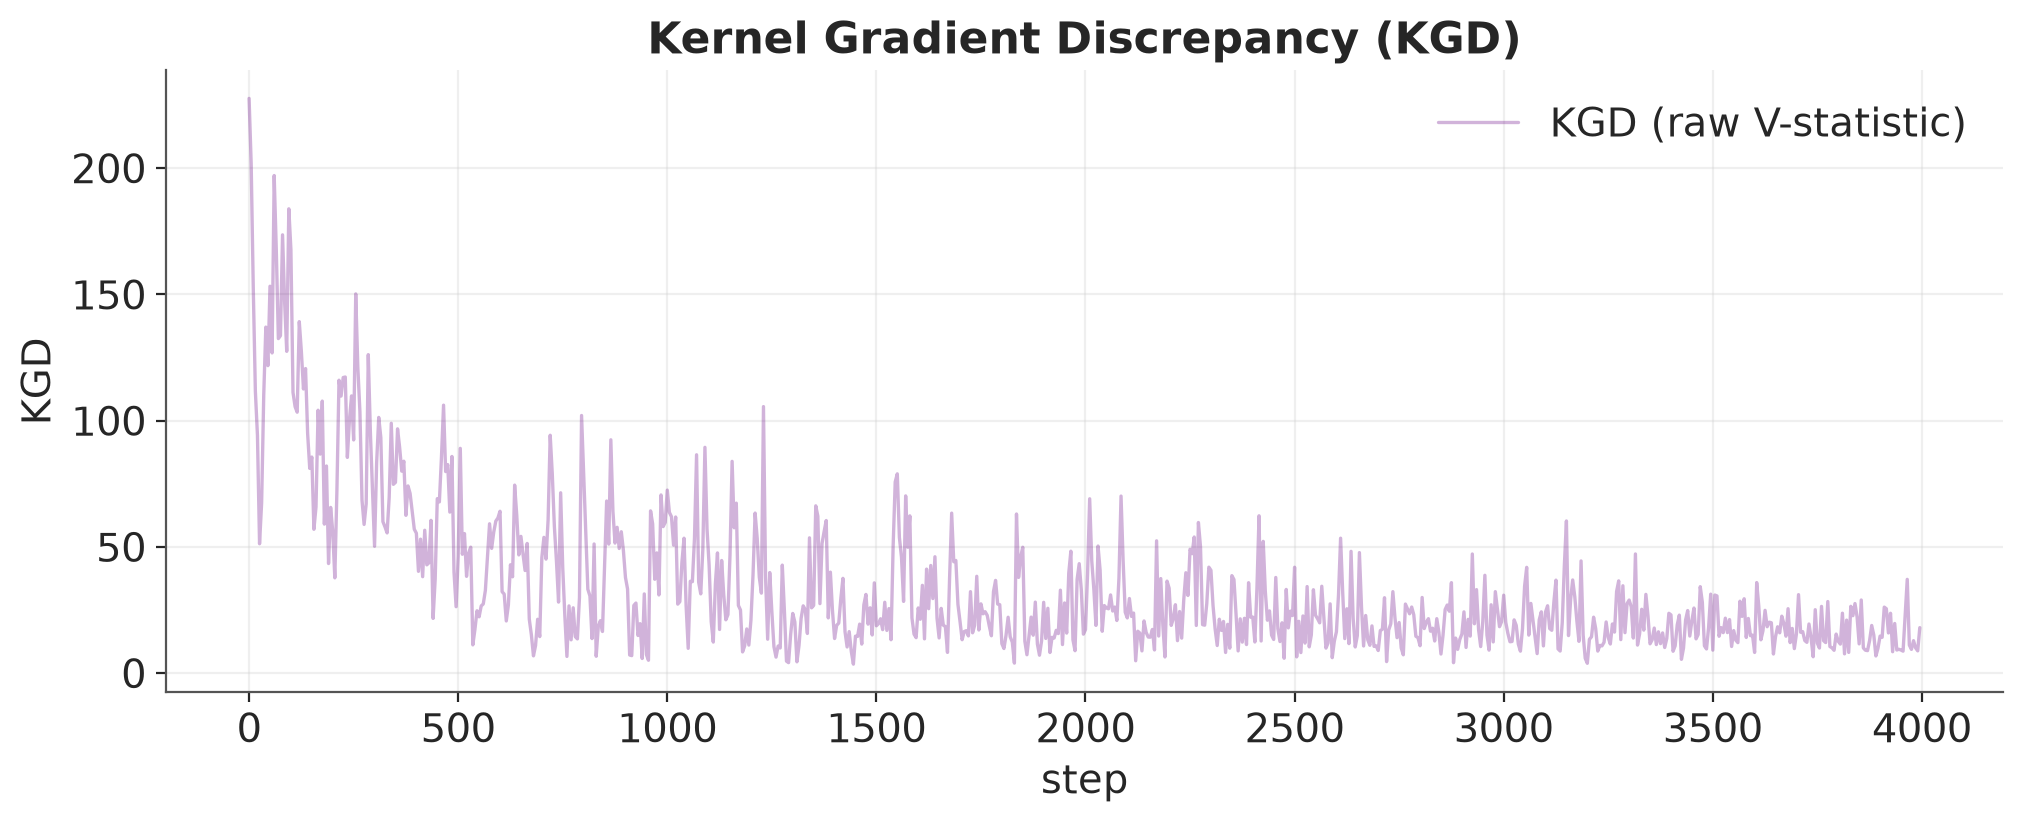

In [12]:
kgd_series = dt.sample_stats["kgd"].isel(chain=0)
kgd_steps = kgd_series.step.values[np.isfinite(kgd_series.values)]
kgd_raw = kgd_series.values[np.isfinite(kgd_series.values)]



_, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    kgd_steps,
    kgd_raw,
    color="C3",
    alpha=0.35,
    lw=1.2,
    label="KGD (raw V-statistic)",
)
ax.set(
    title="Kernel Gradient Discrepancy (KGD)",
    xlabel="step",
    ylabel="KGD",
    #yscale="log",
)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3);


## FUSE schedule diagnostics

When `step_size=None`, FUSE records per-retained-step quantities in `sample_stats`:

- `fuse_step_size`: adaptive step size used that step
- `fuse_gradient_energy`: incremental gradient energy (mean squared raw drift over particles)
- `fuse_half_step_distance_sq`: squared empirical distance between the fixed reference half-step and the current half-step.

These are step-only traces (identical across `chain`); we plot against simulation `step`.

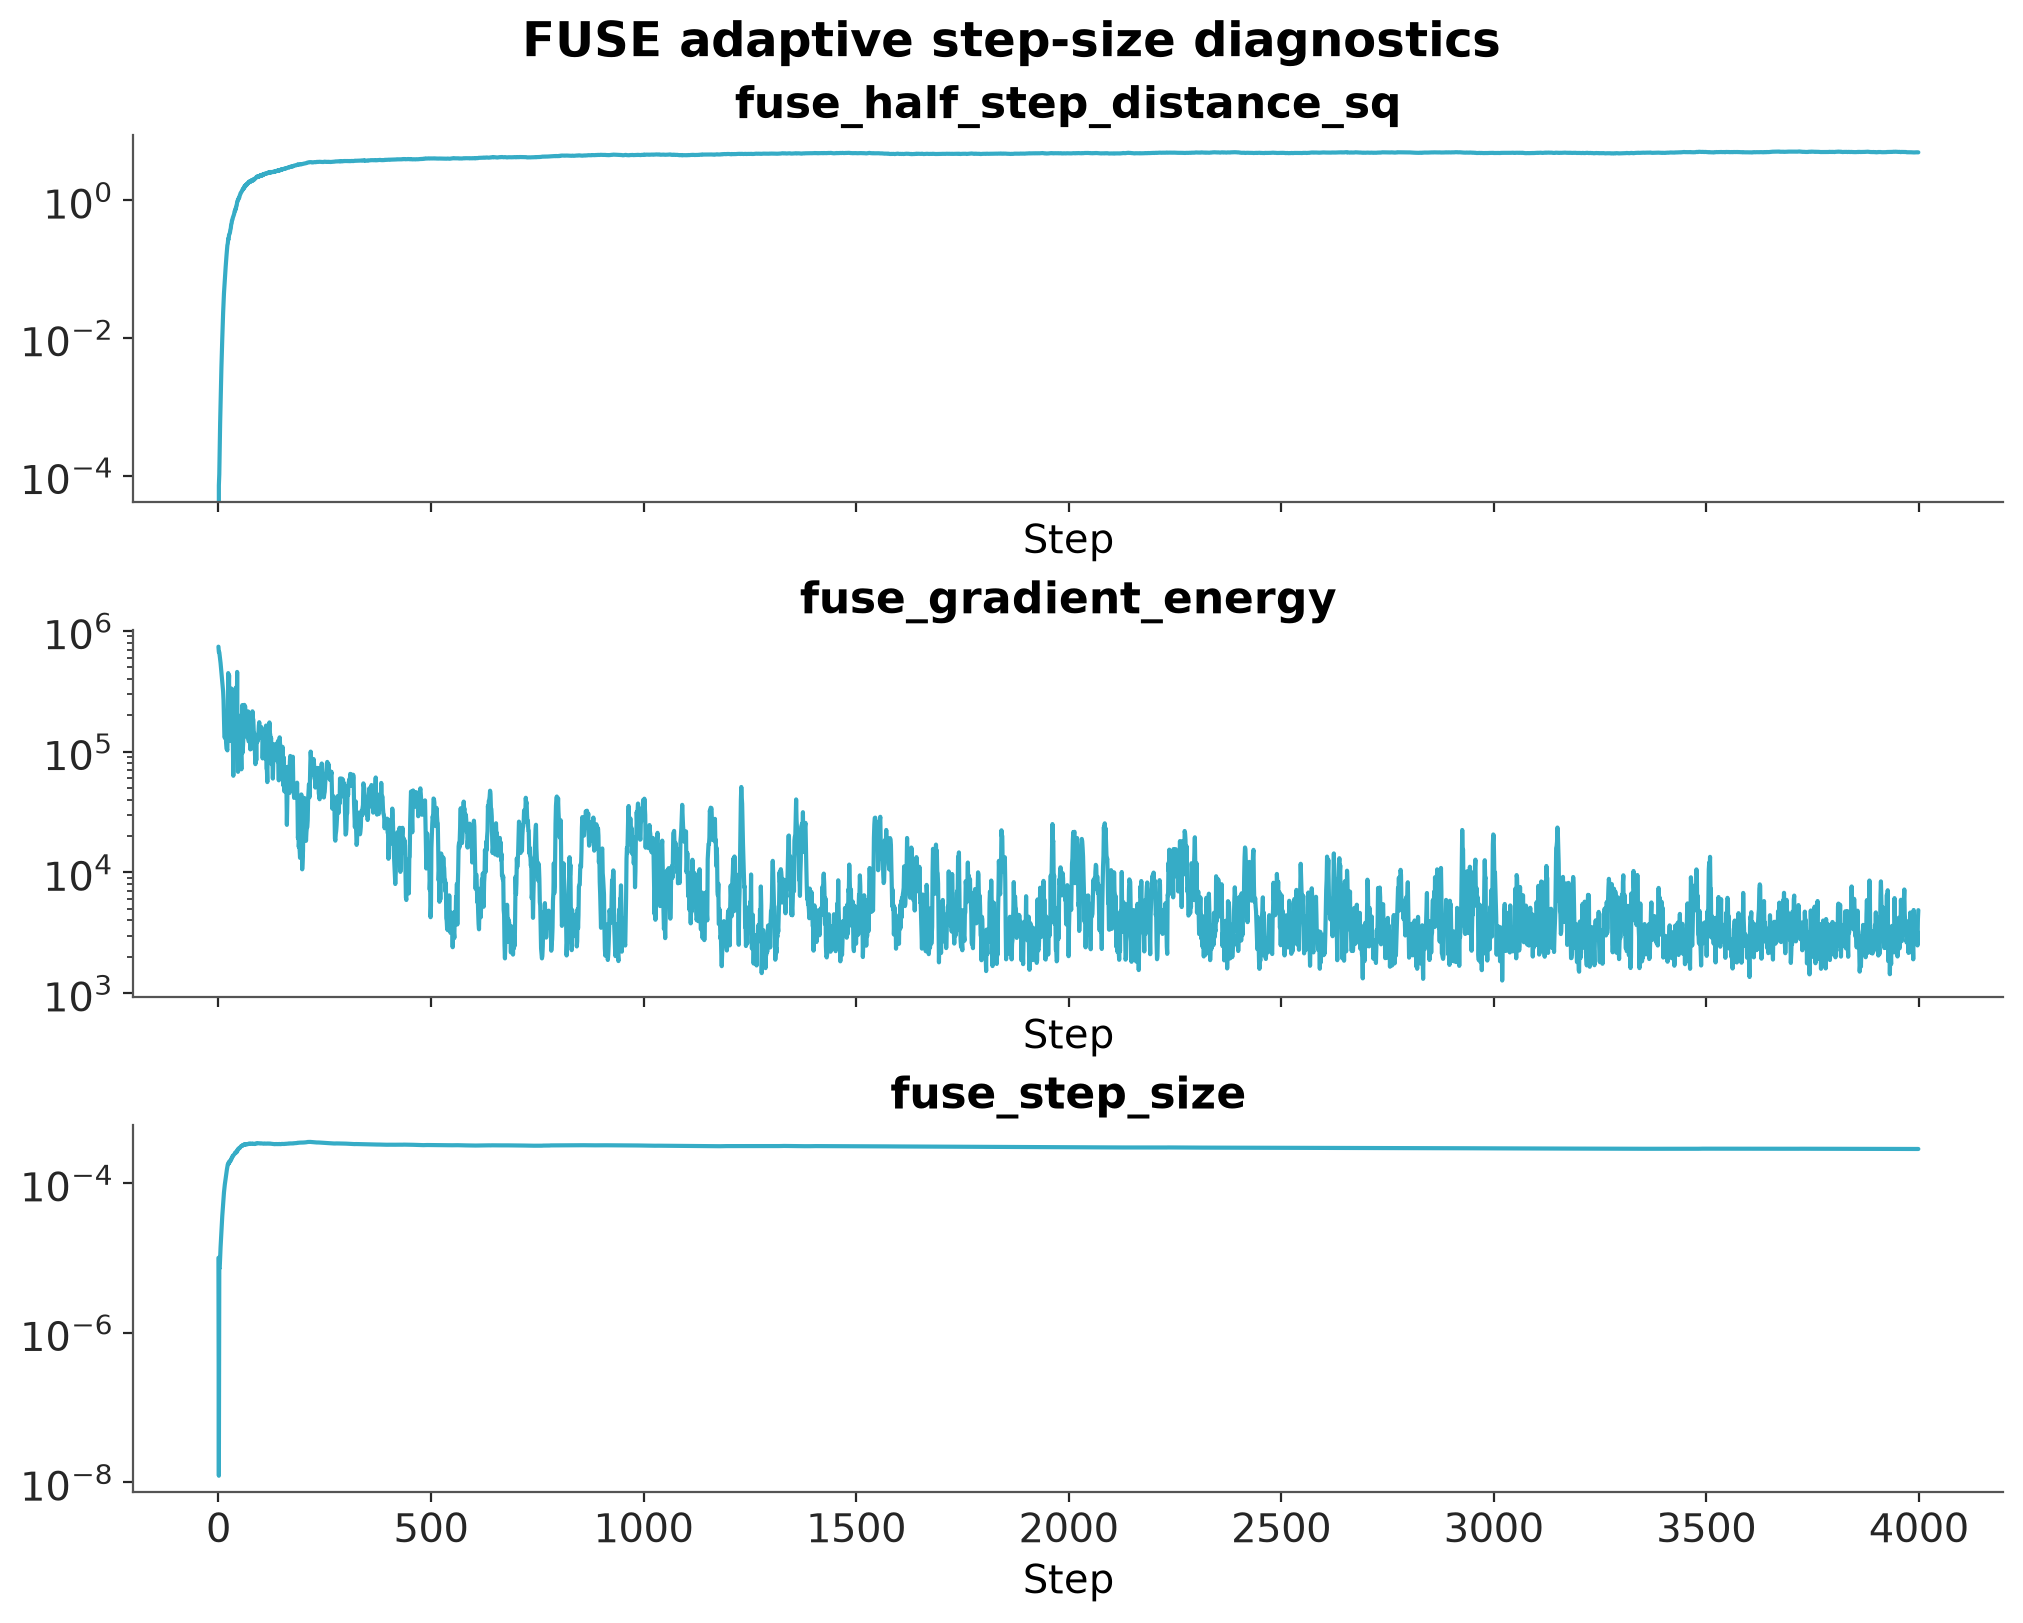

In [13]:
to_plot_dt = dt.sel(chain=[0])
pc = az.plot_trace(
    to_plot_dt,
    var_names=[
        "fuse_half_step_distance_sq",
        "fuse_gradient_energy",
        "fuse_step_size",
    ],
    group="sample_stats",
    visuals={"trace": {"xname": "step"}},
    col_wrap=1,
    figure_kwargs={"figsize": (10, 8)},
)
pc.facet_map("set_yscale", scale="log")
pc.add_title("FUSE adaptive step-size diagnostics")


## Particle trajectories

Each line traces one particle $\theta_t^{(j)} = (\beta_{0,t}^{(j)}, \beta_{1,t}^{(j)}, \beta_{2,t}^{(j)})$. Under misspecification, baseline intercept trajectories $\beta_0$ split across all three true phenotype clearance levels ($\log 17.7 \approx 2.87$, $\log 37.8 \approx 3.63$, $\log 55.9 \approx 4.02$). The allometric exponent $\beta_1$ and age slope $\beta_2$ contract around their true values ($0.75$ and $-0.10$).

/tmp/ipykernel_980/2695632570.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", frameon=True)


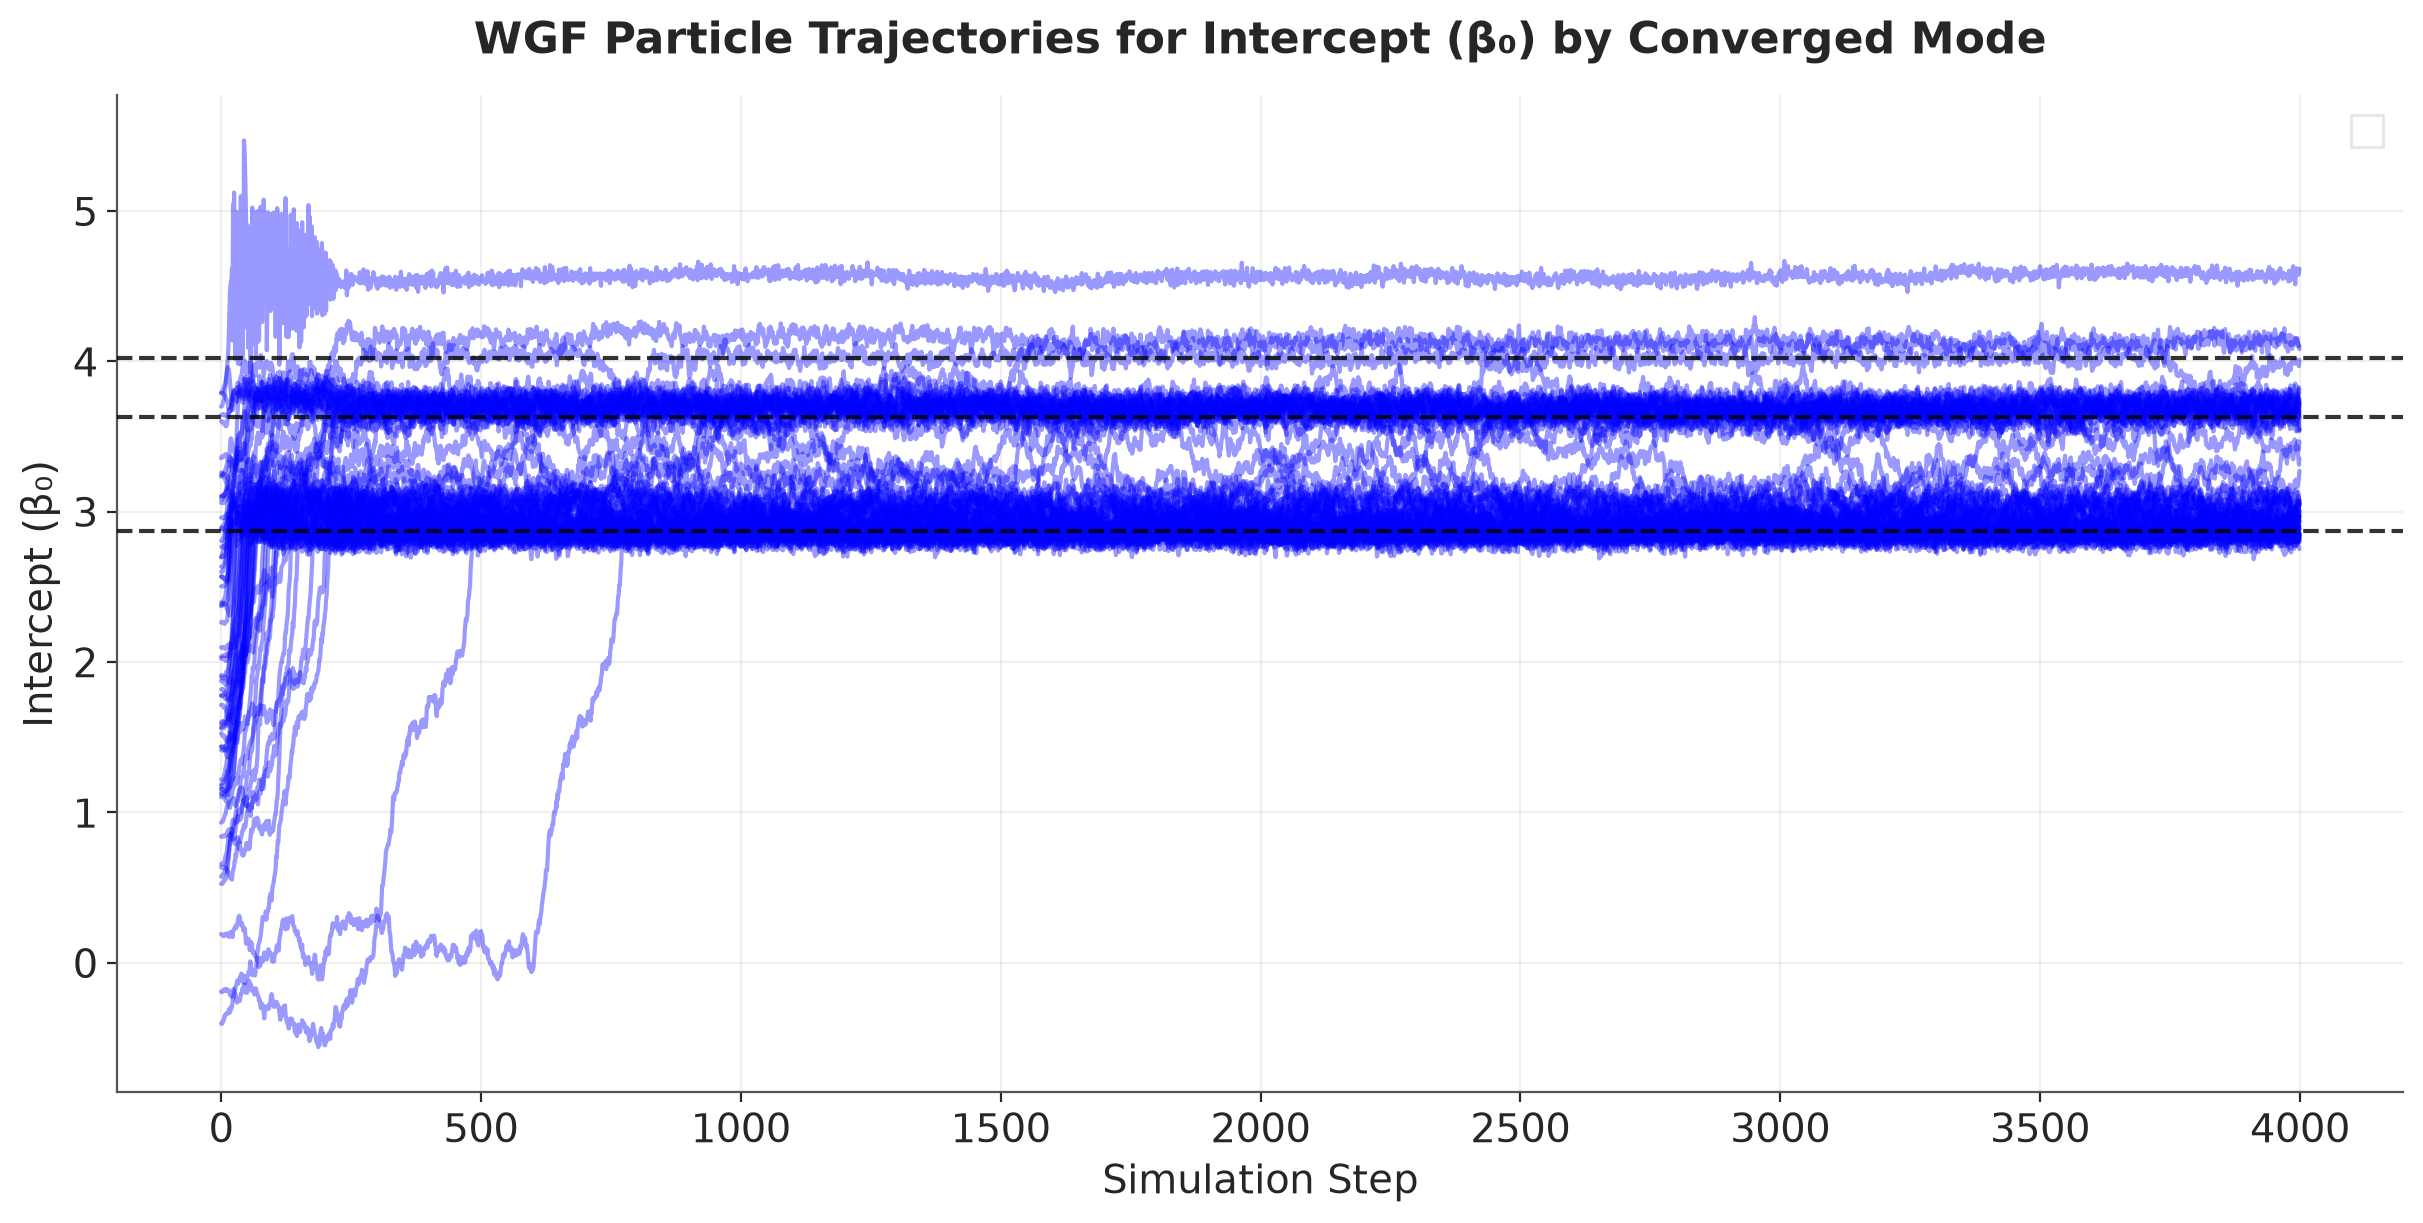

In [25]:
# Extract beta0 trajectories and step numbers from the DataTree
# beta0_traces shape is (800 steps, 60 particles)
beta0_traces = dt.posterior["beta0"].values 
steps = dt.posterior.step.values

fig, ax = plt.subplots(figsize=(12, 6))


# Plot each particle's trajectory
for i in range(beta0_traces.shape[1]):
    particle_path = beta0_traces[:, i]
    ax.plot(steps, particle_path, color="blue", alpha=0.4, lw=1.5)

# Add horizontal lines for the true latent log clearance values
for cl in log_clearances:
    ax.axhline(cl, color="black", linestyle="--", alpha=0.8, zorder=10)

ax.set_title("WGF Particle Trajectories for Intercept (β₀) by Converged Mode", pad=15)
ax.set_xlabel("Simulation Step")
ax.set_ylabel("Intercept (β₀)")
ax.legend(loc="upper right", frameon=True)
ax.grid(True, alpha=0.3)

plt.show()

## Posterior and Bayes predictive check

Sampling: [y]


(1.0, 6.0)

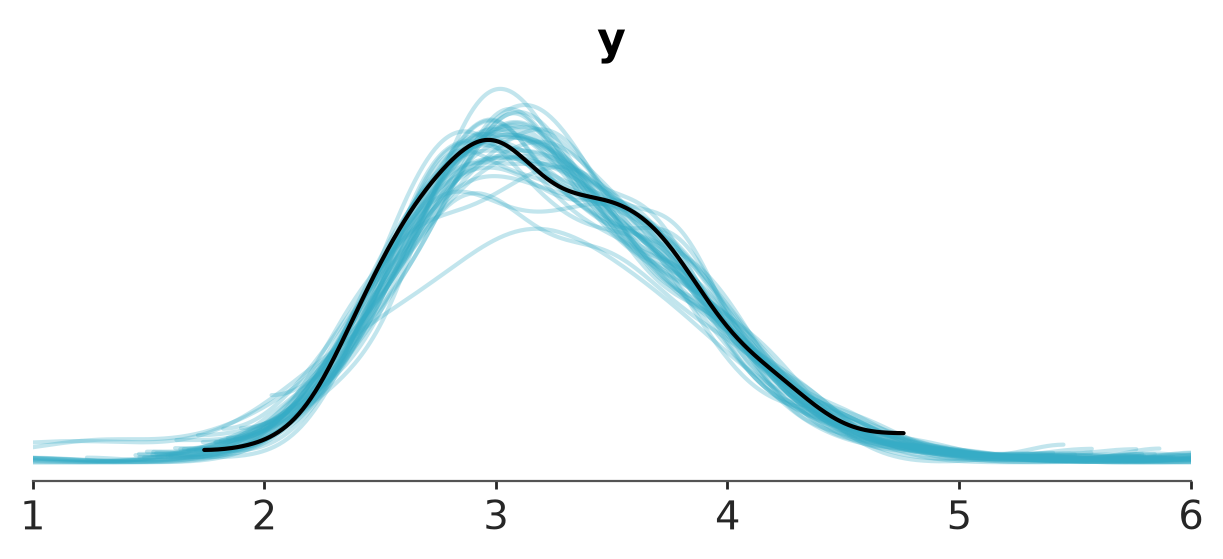

In [32]:
ppc_dt = pro.sample_posterior_predictive_pro(
    dt,
    model=model,
    random_seed=SEED,
)

az.plot_ppc_dist(ppc_dt, num_samples=40)

plt.xlim(1, 6)


Sampling: [y]


/home/patrideo/micromamba/envs/pymc-dev-prop/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/tmp/ipykernel_980/747530580.py:1: UserWarning: groups {'posterior_predictive'} already exist in the DataTree and will be overwritten. To avoid this, set extend_inferencedata=False.
  pm.sample_posterior_predictive(


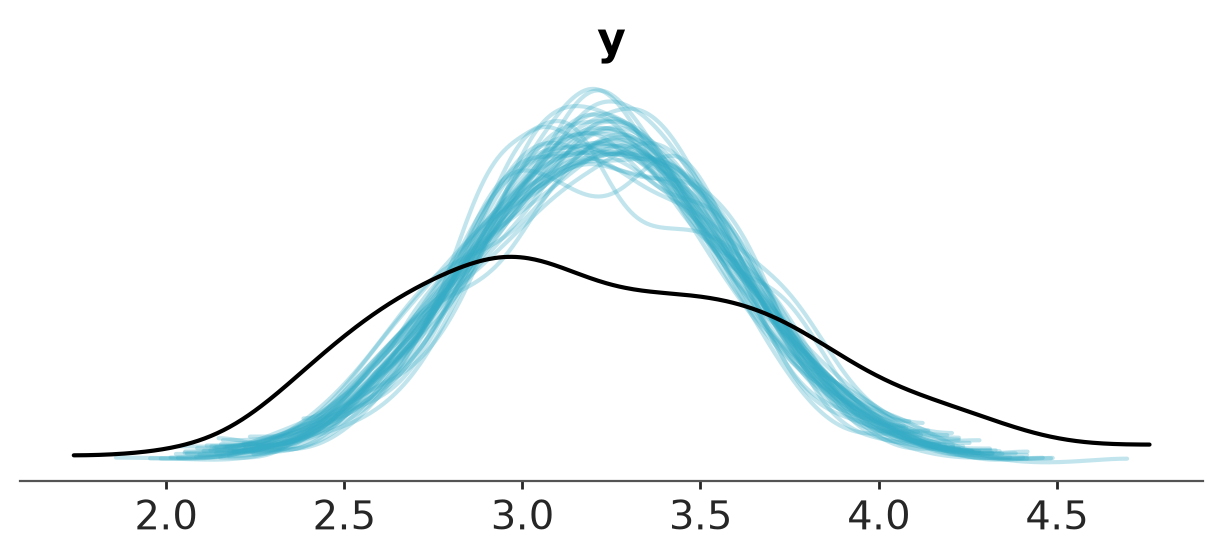

In [29]:
pm.sample_posterior_predictive(
    idata_bayes,
    model=model,
    extend_inferencedata=True,
    random_seed=SEED
)

az.plot_ppc_dist(idata_bayes, num_samples=40)
